# Executive Order Analysis

Analysis over `data/analysis.db`: 1,534 Executive Orders, EO 12890 (1993-12-30) to
EO 14423 (2026-08-28), extracted by `openai/gpt-oss-120b` under prompt v7 (run 11).

Before quoting any number from this notebook, read
[INVESTIGATORS_CHEAT_SHEET.md](../INVESTIGATORS_CHEAT_SHEET.md). The four things it
says most often:

- **Recall was never measured.** "The model extracted X from 66% of orders" is
  supportable; "34% of orders have no X" is not.
- **Count agencies through `agency_taskings`**, ranked by distinct orders, excluding
  `kind IN ('collective', 'generic')`.
- **Filter relationships to `authoritative = 1`** (the `revocation_network` view
  already does).
- **Only `source_quote` is verified.** `summary` and `task` are model prose.

Every cell runs from the repository root with the project venv:

```sh
pip install -e ".[analysis]"
PYTHONPATH=src .venv/bin/jupyter lab notebooks/analysis.ipynb
```

## Setup

In [1]:
import re
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from eo.grounding import is_grounded  # noqa: E402

DB = ROOT / "data" / "analysis.db"
con = sqlite3.connect(f"file:{DB}?mode=ro", uri=True)


def q(sql: str, **params) -> pd.DataFrame:
    """Run a query against analysis.db (read-only) and return a DataFrame."""
    return pd.read_sql_query(sql, con, params=params or None)


pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

# Presidents in chronological order, for consistent axes and tables.
PRESIDENTS = q("SELECT president FROM orders GROUP BY 1 ORDER BY MIN(signing_date)")["president"].tolist()
SHORT = {"William J. Clinton": "Clinton", "George W. Bush": "G.W. Bush", "Barack Obama": "Obama",
         "Donald Trump": "Trump", "Joseph R. Biden Jr.": "Biden"}
print(DB, "opened read-only")

/Users/davidkolet-tassara/Documents/EO_Analysis/data/analysis.db opened read-only


## Sanity checks

The three checks the cheat sheet asks for before anything is published: which model
produced the data, that every stored quote really is in its order's text, and what is
already known to be imperfect.

In [2]:
q("SELECT run_id, model, prompt_version, ROUND(cost_usd, 2) AS cost_usd, coverage FROM run_metadata").T

,0
run_id,11
model,openai/gpt-oss-120b
prompt_version,v7
cost_usd,1.05
coverage,"Executive Orders with full text in the Federal Register API, which begins ~1..."


In [3]:
rows = con.execute(
    "SELECT c.source_quote, t.body_text FROM all_claims c JOIN order_text t USING (document_number)"
).fetchall()
grounded = sum(is_grounded(quote, body) for quote, body in rows)
print(f"{grounded} / {len(rows)} stored quotes appear in their order's text")
assert grounded == len(rows), "a stored quote is not in its source: the build is broken"

8989 / 8989 stored quotes appear in their order's text


In [4]:
q("SELECT kind, COUNT(*) AS items FROM review_queue GROUP BY 1 ORDER BY 2 DESC")

,kind,items
0,dropped_unverifiable,259
1,ungrounded_agencies_tasked,241
2,ungrounded_deadlines,156
3,ungrounded_authorities,77
4,ungrounded_relationships,66
5,relationship,63
6,other_without_reason,4


## Shape of the corpus

Orders per president, per *active* year. Trump's two terms are non-contiguous, so a
first-to-last date span would attribute 2021-24 to him and understate his rate.

In [5]:
shape = q("""
SELECT president,
       COUNT(*) AS orders,
       MIN(signing_date) AS first, MAX(signing_date) AS last,
       COUNT(DISTINCT substr(signing_date, 1, 4)) AS active_years,
       ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT substr(signing_date, 1, 4)), 1) AS per_active_year
FROM orders GROUP BY president ORDER BY MIN(signing_date)
""")
shape

,president,orders,first,last,active_years,per_active_year
0,William J. Clinton,308,1993-12-30,2001-01-18,9,34.2
1,George W. Bush,291,2001-01-29,2009-01-16,9,32.3
2,Barack Obama,276,2009-01-21,2017-01-17,9,30.7
3,Donald Trump,497,2017-01-20,2026-08-28,7,71.0
4,Joseph R. Biden Jr.,162,2021-01-20,2025-01-19,5,32.4


In [6]:
q("""
SELECT 'orders' AS t, COUNT(*) AS n FROM orders
UNION ALL SELECT 'agencies_tasked', COUNT(*) FROM agencies_tasked
UNION ALL SELECT 'deadlines', COUNT(*) FROM deadlines
UNION ALL SELECT 'authorities', COUNT(*) FROM authorities
UNION ALL SELECT 'relationships (authoritative)', COUNT(*) FROM relationships WHERE authoritative = 1
UNION ALL SELECT 'agencies (canonical)', COUNT(*) FROM agencies
""").set_index("t")

,n
t,
orders,1534
agencies_tasked,3195
deadlines,2240
authorities,1707
relationships (authoritative),4849
agencies (canonical),598


## Analysis

Sections below are added as questions are asked. Each one states the query it rests on
and the caveat that applies to it.

### How often does each administration cancel a prior president's orders?

**What counts as cancelling.** The `revokes`, `rescinds` and `supersedes` relations,
in full or in part. `amends` is excluded: an amendment leaves the order in force.
The edge set is the authoritative one (`authoritative = 1`), so where the Federal
Register has a disposition note for a pair it is the single source, and the model's
edges add only pairs the Register is silent about. The Register also writes notes on
the *target* ("Revoked by: EO 13783"); a dozen of those have no matching note on the
revoking order, so they are flipped and added.

**Targets outside the corpus are kept, not dropped.** The `revocation_network` view
requires both ends to be orders in this database, which silently discards every
revocation of a pre-1994 order — all of Clinton's cancellations of Bush 41 and Reagan
orders, for instance. Here a target that names an EO number is attributed to its
signer by number range (from the Federal Register's disposition tables), whether or not
the order itself is in the corpus. Targets with no EO number — memoranda,
proclamations, determinations — are excluded.

**A cancellation cannot precede its target.** Fourteen Federal Register notes say
"Amends" or "Supersedes" where the dates show they mean "Amended by" or "Superseded
by" — EO 13286, the 2003 omnibus amendment, is written that way on eight orders it
amended. A forward edge whose target was signed *after* the acting order is therefore
dropped here; the later order's own note carries the relationship the right way round.

**Trump is split into two terms**, because "Trump 47 revokes a Trump 45 order" is the
same president cancelling his own order, and a single "Trump" row would hide it.
Each (order, target) pair counts once.

In [7]:
# Signer by EO number, for targets outside the corpus. First order of each
# president, from the Federal Register disposition tables.
FIRST_EO = [
    (6071, "F.D. Roosevelt"), (9538, "Truman"), (10432, "Eisenhower"),
    (10914, "Kennedy"), (11128, "L.B. Johnson"), (11452, "Nixon"), (11798, "Ford"),
    (11967, "Carter"), (12287, "Reagan"), (12668, "G.H.W. Bush"), (12834, "Clinton"),
]
ADMINS = ["Clinton", "G.W. Bush", "Obama", "Trump 45", "Biden", "Trump 47"]
SIGNERS = ["before F.D. Roosevelt"] + [name for _, name in FIRST_EO[:-1]] + ADMINS


def administration(president: str, signing_date: str) -> str:
    if president == "Donald Trump":
        return "Trump 45" if signing_date < "2025-01-20" else "Trump 47"
    return SHORT[president]


def signer_by_number(eo: int) -> str:
    name = "before F.D. Roosevelt"
    for first, who in FIRST_EO:
        if eo >= first:
            name = who
    return name


edges = q("""
WITH forward AS (
    SELECT document_number AS src, target_document_number AS tgt,
           target_eo_number AS tgt_eo, relation, in_part, source
    FROM relationships
    WHERE authoritative = 1 AND relation IN ('revokes', 'rescinds', 'supersedes')
),
inbound AS (
    SELECT r.target_document_number AS src, r.document_number AS tgt,
           o.eo_number AS tgt_eo, r.relation, r.in_part, r.source
    FROM relationships r JOIN orders o ON o.document_number = r.document_number
    WHERE r.authoritative = 1
      AND r.relation IN ('revoked_by', 'rescinded_by', 'superseded_by')
      AND r.target_document_number IS NOT NULL
)
SELECT e.src, e.tgt, e.tgt_eo, e.relation, e.in_part, e.source,
       s.eo_number AS src_eo, s.president AS src_president, s.signing_date AS src_date,
       t.president AS tgt_president, t.signing_date AS tgt_date
FROM (SELECT * FROM forward UNION ALL SELECT * FROM inbound) e
JOIN orders s ON s.document_number = e.src
LEFT JOIN orders t ON t.document_number = e.tgt
WHERE e.tgt_eo IS NOT NULL
""")
edges["relation"] = edges["relation"].str.replace("_by", "", regex=False).replace(
    {"revoked": "revokes", "rescinded": "rescinds", "superseded": "supersedes"})
# Federal Register rows first, so the surviving duplicate is the authoritative one.
edges = (edges.sort_values(["source", "in_part"], ascending=[True, True])
              .drop_duplicates(["src", "tgt_eo"]).copy())
inverted = edges.tgt_date.notna() & (edges.tgt_date > edges.src_date)
print(f"{int(inverted.sum())} edges dropped: the target was signed after the acting order")
edges = edges[~inverted].copy()
edges["actor"] = [administration(p, d) for p, d in zip(edges.src_president, edges.src_date)]
edges["target"] = [administration(p, d) if pd.notna(p) else signer_by_number(eo)
                   for p, d, eo in zip(edges.tgt_president, edges.tgt_date, edges.tgt_eo)]
edges["target_in_corpus"] = edges.tgt.notna()
edges["same_person"] = edges.target.str.split().str[0] == edges.actor.str.split().str[0]

print(f"{len(edges)} cancellations of numbered executive orders, "
      f"{edges.target_in_corpus.sum()} with the target in the corpus, "
      f"{(~edges.target_in_corpus).sum()} attributed by EO number; "
      f"{int(edges.in_part.sum())} are in part")
edges.relation.value_counts()

6 edges dropped: the target was signed after the acting order
613 cancellations of numbered executive orders, 478 with the target in the corpus, 135 attributed by EO number; 33 are in part


relation
revokes       496
supersedes    111
rescinds        6
Name: count, dtype: int64

Per administration: how many cancellations, how many of them fell on another
president's orders, and the rate per active year (Trump 47 is a partial term).

In [8]:
active_years = q("""
SELECT president, signing_date FROM orders
""")
active_years["actor"] = [administration(p, d) for p, d in zip(active_years.president, active_years.signing_date)]
active_years = active_years.assign(year=active_years.signing_date.str[:4]).groupby("actor").year.nunique()

by_actor = (edges.groupby("actor")
                 .agg(cancellations=("tgt_eo", "size"),
                      prior_president=("same_person", lambda s: int((~s).sum())),
                      own=("same_person", "sum"),
                      target_outside_corpus=("target_in_corpus", lambda s: int((~s).sum())))
                 .reindex(ADMINS))
by_actor["active_years"] = active_years.reindex(ADMINS)
by_actor["prior_per_active_year"] = (by_actor.prior_president / by_actor.active_years).round(1)
by_actor

,cancellations,prior_president,own,target_outside_corpus,active_years,prior_per_active_year
actor,,,,,,
Clinton,112,52,60,71,9,5.8
G.W. Bush,116,83,33,43,9,9.2
Obama,87,57,30,6,9,6.3
Trump 45,56,42,14,6,5,8.4
Biden,105,96,9,1,5,19.2
Trump 47,137,132,5,8,2,66.0


Whose orders each administration cancelled. Rows are the acting administration;
columns are the signer of the cancelled order, oldest first. Signers left of Clinton are
attributed by EO number, since their orders are outside the corpus.

In [9]:
matrix = (edges.pivot_table(index="actor", columns="target", values="tgt_eo", aggfunc="size", fill_value=0)
               .reindex(index=ADMINS, columns=[s for s in SIGNERS if s in set(edges.target)], fill_value=0))
matrix

target,before F.D. Roosevelt,F.D. Roosevelt,Truman,Eisenhower,Kennedy,L.B. Johnson,Nixon,Ford,Carter,Reagan,G.H.W. Bush,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47
actor,,,,,,,,,,,,,,,,,
Clinton,1,3,1,2,3,3,1,1,6,17,14,60,0,0,0,0,0
G.W. Bush,0,0,0,1,0,2,2,5,0,11,14,48,33,0,0,0,0
Obama,0,0,1,1,0,0,0,1,1,1,1,7,44,30,0,0,0
Trump 45,1,1,0,1,0,1,1,0,0,0,1,2,3,31,14,0,0
Biden,0,0,0,1,0,0,0,0,0,0,0,3,4,12,76,9,0
Trump 47,1,0,0,0,0,2,1,0,3,1,0,3,4,5,1,112,4


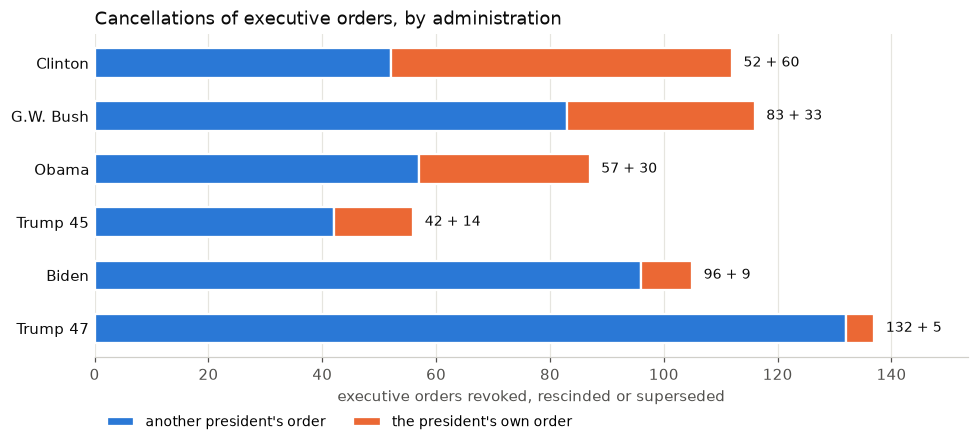

In [10]:
# Series colours: categorical slots 1 and 2 of the reference palette, validated as an
# adjacent pair (CVD dE >= 8, normal-vision dE >= 15).
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"

fig, ax = plt.subplots(figsize=(9, 4.2))
rows = by_actor[::-1]  # chronological top to bottom
y = range(len(rows))
ax.barh(y, rows.prior_president, height=0.55, color=BLUE, label="another president's order",
        edgecolor="white", linewidth=1.5)
ax.barh(y, rows.own, height=0.55, left=rows.prior_president, color=ORANGE,
        label="the president's own order", edgecolor="white", linewidth=1.5)
for i, (prior, own) in enumerate(zip(rows.prior_president, rows.own)):
    ax.text(prior + own + 2, i, f"{int(prior)} + {int(own)}", va="center", fontsize=9, color=INK)
ax.set_yticks(list(y), rows.index)
ax.set_xlabel("executive orders revoked, rescinded or superseded", color=MUTED)
ax.set_title("Cancellations of executive orders, by administration", loc="left", fontsize=12, color=INK)
ax.set_xlim(0, (rows.prior_president + rows.own).max() * 1.12)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, -0.14), ncol=2, fontsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d0cfc9")
ax.tick_params(axis="y", length=0, colors=INK)
ax.tick_params(axis="x", colors=MUTED)
ax.xaxis.grid(True, color="#e6e5df", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Caveats that apply to these numbers.**

- The Federal Register is the authoritative source and its disposition notes are the
  bulk of the edge set. The model's additions are precision-checked (every quote is
  verified) but recall was never measured, so an administration's count is a floor.
- Cancelling *in part* counts as a cancellation. So does `supersedes`.
- Memoranda, proclamations and orders the source names without a number are excluded.
  For the model's edges that is most of what it found: it often cited a section or a
  memorandum rather than an EO number.
- Attribution by EO number for pre-1994 targets rests on the published first-order
  number of each president. A wrong boundary would move a few edges between adjacent
  presidents, never between the "prior" and "own" columns.

### Which agencies did each administration lean on?

**How an agency is counted.** Through the `agency_taskings` view, which resolves the
name each order used to a canonical agency (Secretary of the Treasury and Department
of the Treasury are one institution; Department of War is Defense across the 2025
rename). An agency is credited once per order it appears in, however many times that
order tasks it — the view unions agency taskings with deadline responsibilities, and
30% of (agency, order) pairs appear in both. `collective` ("all agencies") and
`generic` (a bare "Task Force" that means a body created inside its own order) are
excluded, because neither is an entity that spans orders.

**The measure is a share of the administration's orders**, so terms of different
lengths compare. Trump is split into two terms, using the `administration()` helper
from the previous section.

**What a share means.** "The model extracted a tasking of Treasury from 30% of
Biden's orders." Recall was never measured, so an agency's absence from an order is
not evidence the order did not task it, and every share is a floor.

In [11]:
taskings = q("""
SELECT canonical_name, kind, document_number, president, signing_date
FROM agency_taskings
WHERE kind NOT IN ('collective', 'generic')
""")
taskings["actor"] = [administration(p, d) for p, d in zip(taskings.president, taskings.signing_date)]
# One credit per (agency, order): the view records the same obligation twice when an
# order both tasks an agency and sets it a deadline.
pairs = taskings.drop_duplicates(["canonical_name", "document_number"])

orders_all = q("SELECT document_number, president, signing_date FROM orders")
orders_all["actor"] = [administration(p, d) for p, d in zip(orders_all.president, orders_all.signing_date)]
orders_per_actor = orders_all.actor.value_counts().reindex(ADMINS)

breadth = pd.DataFrame({
    "orders": orders_per_actor,
    "orders_with_a_tasking": pairs.groupby("actor").document_number.nunique().reindex(ADMINS),
    "distinct_agencies": pairs.groupby("actor").canonical_name.nunique().reindex(ADMINS),
})
breadth["share_with_a_tasking"] = (breadth.orders_with_a_tasking / breadth.orders * 100).round(0).astype(int)
breadth["agencies_per_tasking_order"] = (pairs.groupby("actor").size().reindex(ADMINS) / breadth.orders_with_a_tasking).round(1)
breadth

,orders,orders_with_a_tasking,distinct_agencies,share_with_a_tasking,agencies_per_tasking_order
actor,,,,,
Clinton,308,152,139,49,2.0
G.W. Bush,291,139,102,48,1.8
Obama,276,173,172,63,2.1
Trump 45,220,170,125,77,2.3
Biden,162,113,103,70,3.2
Trump 47,277,247,144,89,2.7


The top eight agencies of each administration, by the number of its orders that task
them. The number in brackets is that count.

In [12]:
SHORT_AGENCY = {
    "Department of Health and Human Services": "HHS", "Department of Homeland Security": "DHS",
    "Office of Management and Budget": "OMB", "Office of Personnel Management": "OPM",
    "Executive Office of the President": "EOP", "Environmental Protection Agency": "EPA",
    "Office of Science and Technology Policy": "OSTP", "General Services Administration": "GSA",
}


def short_agency(name: str) -> str:
    if name in SHORT_AGENCY:
        return SHORT_AGENCY[name]
    for prefix in ("Department of the ", "Department of "):
        if name.startswith(prefix):
            return name[len(prefix):]
    return name


counts = pairs.groupby(["actor", "canonical_name"]).size().rename("orders").reset_index()
top8 = {}
for actor in ADMINS:
    rows = counts[counts.actor == actor].nlargest(8, "orders")
    top8[actor] = [f"{short_agency(n)} ({o})" for n, o in zip(rows.canonical_name, rows.orders)]
pd.DataFrame(top8, index=range(1, 9))

,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47
1,Defense (16),Treasury (20),Treasury (30),Treasury (31),OMB (28),Justice (58)
2,Treasury (16),The President (16),State (15),HHS (25),HHS (24),DHS (49)
3,The President (16),Defense (14),OMB (15),State (25),DHS (23),Commerce (46)
4,Justice (11),State (13),The President (15),DHS (24),Defense (18),State (39)
5,OPM (11),DHS (11),EOP (12),Commerce (20),Treasury (18),Defense (33)
6,Commerce (9),HHS (9),HHS (10),Justice (20),State (16),OMB (32)
7,HHS (9),Justice (9),Labor (10),OMB (15),Justice (13),Treasury (29)
8,OMB (9),Commerce (8),Defense (9),OPM (15),Commerce (11),HHS (19)


The same measure as a share of each administration's orders, for the twelve agencies
tasked in the most orders overall. Reading down a column shows an administration's
profile; reading across a row shows an agency's rise or fall.

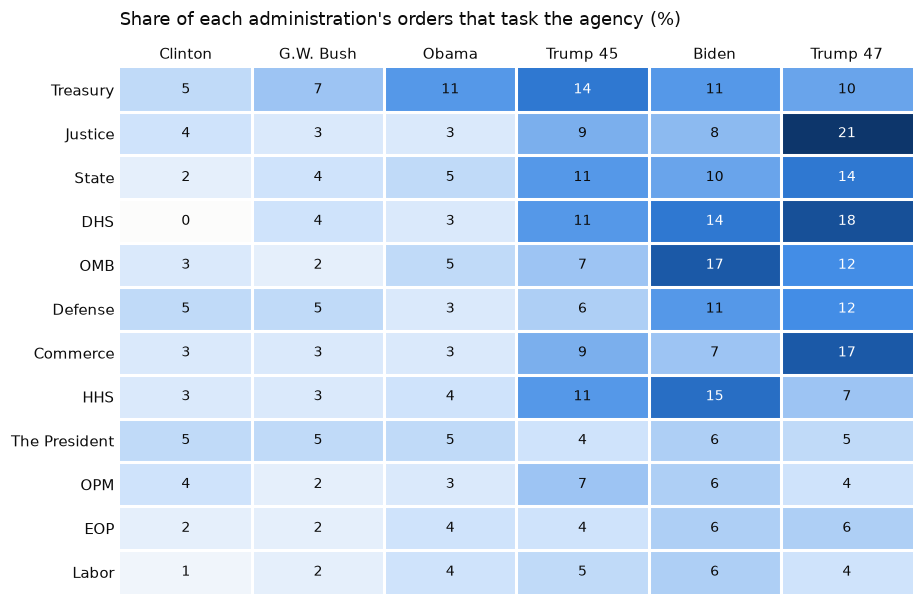

In [13]:
from matplotlib.colors import LinearSegmentedColormap

TOP_N = 12
top_agencies = pairs.canonical_name.value_counts().head(TOP_N).index
share = (counts[counts.canonical_name.isin(top_agencies)]
         .pivot(index="canonical_name", columns="actor", values="orders")
         .reindex(index=top_agencies, columns=ADMINS).fillna(0))
share = (share.div(orders_per_actor, axis=1) * 100).round(0)

# One hue, light to dark: the reference palette's sequential blue ramp.
RAMP = LinearSegmentedColormap.from_list("blue", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])

fig, ax = plt.subplots(figsize=(8.5, 5.6))
im = ax.imshow(share.values, cmap=RAMP, vmin=0, vmax=share.values.max(), aspect="auto")
ax.set_xticks(range(len(ADMINS)), ADMINS)
ax.set_yticks(range(TOP_N), [short_agency(n) for n in share.index])
ax.xaxis.tick_top()
ax.tick_params(length=0, colors=INK)
for i in range(TOP_N):
    for j in range(len(ADMINS)):
        v = share.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9,
                color="white" if v >= 0.55 * share.values.max() else INK)
# 2px surface gaps between cells
ax.set_xticks([x - 0.5 for x in range(1, len(ADMINS))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, TOP_N)], minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
for side in ax.spines.values():
    side.set_visible(False)
ax.set_title("Share of each administration's orders that task the agency (%)",
             loc="left", fontsize=12, color=INK, pad=28)
plt.tight_layout()
plt.show()

**Caveats that apply to these numbers.**

- Shares are floors: recall was never measured, so "tasks DHS in 17% of orders" means
  the model extracted such a tasking from 17%, not that 83% did not task DHS.
- The Department of Homeland Security did not exist until November 2002, so its
  G.W. Bush share covers only part of that term.
- `The President` appears as an agency where an order assigns a duty to the
  President in person, typically appointments. Bodies named after the office
  ("President's Council on ...") are separate entities and are not counted here.
- 18% of agency mentions did not match the alias table and stand as their own
  one-off entities. They are in the breadth figures but never reach a top-eight list,
  which is the point: they are commissions and task forces that appear once.

### Topic mix by administration

**What `primary_topic` is.** One of fourteen subject domains, or `other`, assigned by
the model to each order under prompt v7. It is the dataset's weakest verified field:
on the 20-order gold set the cheap model agreed with hand labels 90% of the time, but
against a frontier model on 36 orders it missed one topic in five, always by defaulting
to `government_administration` or `foreign_policy` where a specific domain applied.
Read the shares below as indicative, and expect `government_administration` to be
somewhat inflated at the expense of the specific domains.

**What `other` is.** A vocabulary gap, not a finding about the orders. On the topic
axis it is 1.8% and its reasons are true one-offs (a millennium commemoration, the
Army–Navy football broadcast). It is kept as its own row rather than dropped.

Shares are of each administration's orders, with Trump split into two terms.

In [14]:
TOPIC_ORDER = q("SELECT primary_topic FROM orders GROUP BY 1 ORDER BY COUNT(*) DESC")["primary_topic"].tolist()
TOPIC_ORDER = [t for t in TOPIC_ORDER if t != "other"] + ["other"]

topics = q("SELECT document_number, president, signing_date, primary_topic FROM orders")
topics["actor"] = [administration(p, d) for p, d in zip(topics.president, topics.signing_date)]

topic_counts = (topics.pivot_table(index="primary_topic", columns="actor", values="document_number", aggfunc="size", fill_value=0)
                      .reindex(index=TOPIC_ORDER, columns=ADMINS, fill_value=0))
topic_share = (topic_counts / topic_counts.sum() * 100).round(1)
topic_share["corpus"] = (topic_counts.sum(axis=1) / topic_counts.values.sum() * 100).round(1)
topic_share

actor,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47,corpus
primary_topic,,,,,,,
government_administration,23.1,35.1,28.3,22.7,25.3,20.2,25.9
energy_and_environment,17.9,9.6,11.2,10.9,8.0,13.7,12.3
foreign_policy,10.1,14.1,14.1,10.5,12.3,7.2,11.3
justice_and_law_enforcement,4.9,6.9,7.6,10.9,9.9,11.9,8.4
technology_and_research,9.4,5.5,6.9,10.5,9.9,9.4,8.4
health,6.2,5.8,5.1,11.4,10.5,5.8,7.0
security_and_defense,6.2,6.2,6.2,2.7,3.7,4.7,5.1
trade,3.9,1.7,4.0,3.2,0.0,11.6,4.4
education,3.6,3.4,2.5,4.1,5.6,5.4,4.0


Each administration's three largest domains, with the share of its orders.

In [15]:
def label(topic: str) -> str:
    return topic.replace("_and_", " & ").replace("_", " ")


top3 = {}
for actor in ADMINS:
    s = topic_share[actor].drop("other").nlargest(3)
    top3[actor] = [f"{label(t)} ({v:.0f}%)" for t, v in s.items()]
pd.DataFrame(top3, index=[1, 2, 3])

,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47
1,government administration (23%),government administration (35%),government administration (28%),government administration (23%),government administration (25%),government administration (20%)
2,energy & environment (18%),foreign policy (14%),foreign policy (14%),health (11%),foreign policy (12%),energy & environment (14%)
3,foreign policy (10%),energy & environment (10%),energy & environment (11%),energy & environment (11%),health (10%),justice & law enforcement (12%)


Where each administration departs from the corpus as a whole: the difference, in
percentage points, between its share of a domain and the all-corpus share. Blue is
above the corpus average, red below; the midpoint is grey so "no difference" reads as
nothing.

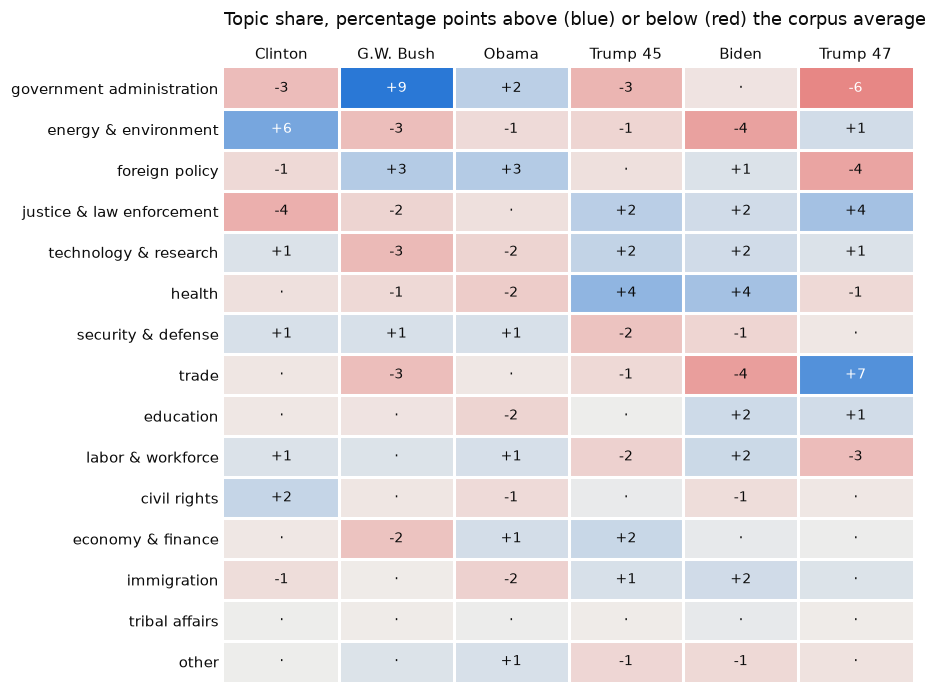

In [16]:
from matplotlib.colors import TwoSlopeNorm

deviation = topic_share[ADMINS].sub(topic_share["corpus"], axis=0)
limit = float(abs(deviation.values).max())

# Diverging: blue (above) <-> neutral grey <-> red (below), from the reference palette.
DIVERGING = LinearSegmentedColormap.from_list("bwr_palette", ["#e34948", "#f0efec", "#2a78d6"])

fig, ax = plt.subplots(figsize=(8.5, 6.4))
ax.imshow(deviation.values, cmap=DIVERGING, norm=TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit), aspect="auto")
ax.set_xticks(range(len(ADMINS)), ADMINS)
ax.set_yticks(range(len(TOPIC_ORDER)), [label(t) for t in TOPIC_ORDER])
ax.xaxis.tick_top()
ax.tick_params(length=0, colors=INK)
for i in range(len(TOPIC_ORDER)):
    for j in range(len(ADMINS)):
        v = deviation.values[i, j]
        ax.text(j, i, f"{v:+.0f}" if abs(v) >= 1 else "·", ha="center", va="center", fontsize=9,
                color="white" if abs(v) >= 0.6 * limit else INK)
ax.set_xticks([x - 0.5 for x in range(1, len(ADMINS))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(TOPIC_ORDER))], minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
for side in ax.spines.values():
    side.set_visible(False)
ax.set_title("Topic share, percentage points above (blue) or below (red) the corpus average",
             loc="left", fontsize=11.5, color=INK, pad=28)
plt.tight_layout()
plt.show()

**Caveats that apply to these numbers.**

- `primary_topic` is the cheap model's reading, and its known bias is toward
  `government_administration`. A frontier re-sweep would move roughly one order in
  five to a more specific domain, which would lower that row and raise others.
- One topic per order. An order that creates a task force on cybersecurity in the
  health sector is one of `technology_and_research` or `health`, not both; secondary
  topics exist for only 192 orders and are not used here.
- Deviations for Biden and Trump 47 rest on 162 and 277 orders, so a difference of a
  point or two is a handful of orders.
- `tribal_affairs` has three orders in the whole corpus; its row is shown for
  completeness and carries no signal.

### Does the text support the topic labels? An audit from the source text

`primary_topic` is the dataset's weakest verified field, and the only check it has had
is twenty gold labels. The source text of every order is in `order_text`, so a second
check is free: **train a text classifier on the model's own labels, with
cross-validation, and see where the text disagrees with the label.**

**What this measures, and what it does not.** The classifier learns from the model's
labels, so it measures *internal consistency*: an order whose words look like the
other `health` orders but which is labelled `government_administration` is a
candidate for review, not a proven error. A topic the model labelled consistently but
wrongly everywhere would pass unnoticed. The twenty gold labels are the one external
anchor, and they are checked last.

**Method.** TF-IDF over the full body text, with English stop words plus the words
every executive order uses regardless of subject ("section", "shall", "agency",
"order"). A linear SVM with balanced class weights — without balancing, a
classifier on this corpus pulls a quarter of the specific-domain orders into
`government_administration`, the largest class, and would manufacture exactly the
bias it was meant to test — under five-fold stratified cross-validation, so every
prediction is made by a model that never saw that order. `tribal_affairs` has three
orders in the corpus and is left out.

In [17]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict

EO_STOP = {
    "section", "sec", "shall", "order", "executive", "orders", "agency", "agencies",
    "president", "federal", "united", "states", "government", "act", "authority",
    "law", "laws", "subject", "provisions", "provision", "purpose", "policy", "sections",
    "including", "pursuant", "consistent", "applicable", "appropriate", "head", "heads",
    "department", "departments", "secretary", "director", "office", "officer", "officers",
    "vested", "constitution", "hereby", "ordered", "amended", "revoked", "general",
    "date", "days", "year", "years", "day", "term", "terms", "means", "title", "code",
    "u", "s", "c", "et", "seq", "usc", "stat", "shall", "may", "person", "persons",
    "official", "officials", "entity", "entities", "member", "members", "white", "house",
    "tiff", "graphic", "omitted",  # "[GRAPHIC] [TIFF OMITTED]" placeholders for annexes
}
STOP = list(ENGLISH_STOP_WORDS | EO_STOP)

text = q("""
SELECT o.document_number, o.eo_number, o.title, o.president, o.signing_date,
       o.primary_topic, t.body_text
FROM orders o JOIN order_text t USING (document_number)
""")
text["actor"] = [administration(p, d) for p, d in zip(text.president, text.signing_date)]

vec = TfidfVectorizer(stop_words=STOP, token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{2,}\b",
                      min_df=5, max_df=0.5, sublinear_tf=True, ngram_range=(1, 2))
X_all = vec.fit_transform(text.body_text)
print(f"{X_all.shape[0]} orders, {X_all.shape[1]:,} terms (unigrams and bigrams)")

audit = text[text.primary_topic != "tribal_affairs"].reset_index(drop=True)
X = X_all[(text.primary_topic != "tribal_affairs").values]
y = audit.primary_topic.values
clf = LinearSVC(C=1, class_weight="balanced")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
margin = cross_val_predict(clf, X, y, cv=cv, method="decision_function")
classes = sorted(set(y))
audit["text_topic"] = [classes[i] for i in margin.argmax(axis=1)]
# Margin between the best and second-best class: how sure the text model is.
top2 = np.sort(margin, axis=1)[:, -2:]
audit["margin"] = (top2[:, 1] - top2[:, 0]).round(2)
audit["agrees"] = audit.text_topic == audit.primary_topic
print(f"text and label agree on {audit.agrees.mean():.0%} of {len(audit)} orders (cross-validated)")

1534 orders, 20,162 terms (unigrams and bigrams)


text and label agree on 70% of 1531 orders (cross-validated)


Per topic: how consistently the label was applied, read as the share of each topic's
orders whose text the classifier assigns back to the same topic. A low share means
the orders under that label do not read alike, or that the label overlaps with
another.

In [18]:
per_topic = (audit.groupby("primary_topic")
                  .agg(orders=("agrees", "size"), text_agrees=("agrees", "mean"))
                  .assign(text_agrees=lambda d: (d.text_agrees * 100).round(0).astype(int))
                  .sort_values("orders", ascending=False))
per_topic["most_common_reassignment"] = [
    (audit[(audit.primary_topic == t) & ~audit.agrees].text_topic.value_counts().index[:1].tolist() or ["—"])[0]
    for t in per_topic.index
]
per_topic

,orders,text_agrees,most_common_reassignment
primary_topic,,,
government_administration,398,74,security_and_defense
energy_and_environment,189,78,foreign_policy
foreign_policy,174,80,government_administration
justice_and_law_enforcement,129,65,government_administration
technology_and_research,129,72,government_administration
health,108,85,government_administration
security_and_defense,79,42,government_administration
trade,67,85,government_administration
education,61,75,government_administration


The confusion between labels and text, as a share of each label's orders (rows sum
to 100). The diagonal is agreement; an off-diagonal cell is where the text of orders
under one label reads like another.

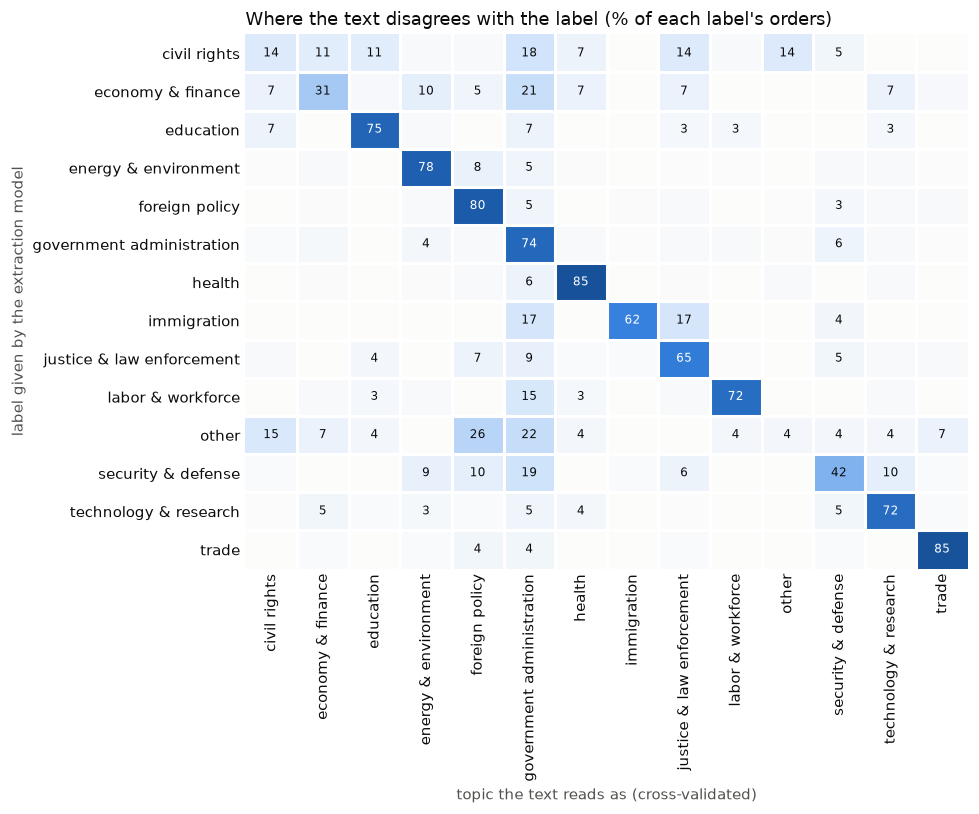

In [19]:
conf = (pd.crosstab(audit.primary_topic, audit.text_topic)
          .reindex(index=classes, columns=classes, fill_value=0))
conf_pct = conf.div(conf.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 7.5))
ax.imshow(conf_pct.values, cmap=RAMP, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(classes)), [label(c) for c in classes], rotation=90)
ax.set_yticks(range(len(classes)), [label(c) for c in classes])
ax.tick_params(length=0, colors=INK)
for i in range(len(classes)):
    for j in range(len(classes)):
        v = conf_pct.values[i, j]
        if v >= 3:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if v >= 55 else INK)
ax.set_xticks([x - 0.5 for x in range(1, len(classes))], minor=True)
ax.set_yticks([y_ - 0.5 for y_ in range(1, len(classes))], minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
for side in ax.spines.values():
    side.set_visible(False)
ax.set_ylabel("label given by the extraction model", color=MUTED)
ax.set_xlabel("topic the text reads as (cross-validated)", color=MUTED)
ax.set_title("Where the text disagrees with the label (% of each label's orders)",
             loc="left", fontsize=11.5, color=INK)
plt.tight_layout()
plt.show()

**The known bias, tested.** The frontier comparison found the cheap model defaulting to
`government_administration` where a specific domain applied. If the text agreed, the
disagreements would concentrate in that row and run *out of* it toward specific
domains. Below, both directions are counted, followed by the disagreements the text
model is surest about — its review list.

In [20]:
ga = audit[audit.primary_topic == "government_administration"]
print(f"government_administration: {len(ga)} orders, text reassigns {(~ga.agrees).sum()} ({(~ga.agrees).mean():.0%})")
print("reassigned to:", ga[~ga.agrees].text_topic.value_counts().head(6).to_dict())
into_ga = audit[(audit.primary_topic != "government_administration") & (audit.text_topic == "government_administration")]
print(f"the reverse -- specific labels the text reads as government_administration: {len(into_ga)}")

# The disagreements the classifier is most sure about: the review list.
review = (audit[~audit.agrees]
          .sort_values("margin", ascending=False)
          [["eo_number", "actor", "title", "primary_topic", "text_topic", "margin"]]
          .head(20))
review.assign(title=review.title.str.slice(0, 70))

government_administration: 398 orders, text reassigns 104 (26%)
reassigned to: {'security_and_defense': 24, 'energy_and_environment': 14, 'economy_and_finance': 11, 'health': 9, 'foreign_policy': 8, 'labor_and_workforce': 8}
the reverse -- specific labels the text reads as government_administration: 101


,eo_number,actor,title,primary_topic,text_topic,margin
1210,14102,Biden,Ordering the Selected Reserve and Certain Members of the Individual Re,government_administration,security_and_defense,1.72
1495,14388,Trump 47,Continuing the Suspension of Duty-Free De Minimis Treatment for All Co,other,trade,1.67
1307,14200,Trump 47,Amendment to Duties Addressing the Synthetic Opioid Supply Chain in th,foreign_policy,trade,1.61
1457,14350,Trump 47,Further Extending the TikTok Enforcement Delay,justice_and_law_enforcement,technology_and_research,1.55
172,13062,Clinton,Continuance of Certain Federal Advisory Committees and Amendments to E,other,government_administration,1.50
845,13737,Obama,Providing an Order of Succession Within the Environmental Protection A,energy_and_environment,government_administration,1.45
979,13871,Trump 45,"Imposing Sanctions With Respect to the Iron, Steel, Aluminum, and Copp",economy_and_finance,foreign_policy,1.44
1477,14370,Trump 47,Increasing Medical Marijuana and Cannabidiol Research,technology_and_research,health,1.42
37,12927,Clinton,Ordering the Selected Reserve of the Armed Forces to Active Duty,government_administration,security_and_defense,1.42
1344,14237,Trump 47,Addressing Risks From Paul Weiss,security_and_defense,justice_and_law_enforcement,1.42


**The external anchor.** For the twenty gold orders, three readings side by side: the
hand label, the extraction model's label, and the text classifier's. The classifier
never saw the gold labels.

In [21]:
import json
gold = {g["eo_number"]: g["primary_topic"] for g in json.load(open(ROOT / "gold" / "gold_set.json"))["labels"]}
g = audit[audit.eo_number.isin(gold)].copy()
g["gold_topic"] = g.eo_number.map(gold)
g["model_ok"] = g.primary_topic == g.gold_topic
g["text_ok"] = g.text_topic == g.gold_topic
print(f"gold set: extraction model agrees on {g.model_ok.sum()}/{len(g)}, text classifier on {g.text_ok.sum()}/{len(g)}")
g[["eo_number", "gold_topic", "primary_topic", "text_topic", "model_ok", "text_ok"]].sort_values("eo_number")

gold set: extraction model agrees on 18/20, text classifier on 12/20


,eo_number,gold_topic,primary_topic,text_topic,model_ok,text_ok
0,12890,technology_and_research,technology_and_research,technology_and_research,True,True
75,12965,energy_and_environment,energy_and_environment,technology_and_research,True,False
150,13040,health,health,health,True,True
225,13115,security_and_defense,security_and_defense,energy_and_environment,True,False
307,13198,government_administration,government_administration,foreign_policy,True,False
377,13268,foreign_policy,foreign_policy,foreign_policy,True,True
447,13338,foreign_policy,foreign_policy,foreign_policy,True,True
598,13489,government_administration,government_administration,justice_and_law_enforcement,True,False
663,13554,energy_and_environment,energy_and_environment,energy_and_environment,True,True
728,13619,foreign_policy,foreign_policy,foreign_policy,True,True


#### Distinctive vocabulary by administration

The same term matrix answers a different question: which words does each
administration use far more than the others? This is the log-odds ratio with an
informative Dirichlet prior (Monroe, Colaresi and Quinn, 2008), which scores a word
by how much more often one administration uses it than the rest of the corpus,
shrunk toward zero for rare words. It reports words, not sentiment, and it is the
defensible version of the "how do they talk" question parked in
ROUND_TWO_QUESTIONS.md.

In [22]:
import numpy as np

counter = CountVectorizer(stop_words=STOP, token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{2,}\b", min_df=5)
C = counter.fit_transform(text.body_text)
vocab = np.array(counter.get_feature_names_out())
total = np.asarray(C.sum(axis=0)).ravel()
alpha = total * (len(vocab) / total.sum())  # informative prior, scaled to vocabulary size
alpha0 = alpha.sum()

distinctive = {}
for actor in ADMINS:
    mask = (text.actor == actor).values
    a = np.asarray(C[mask].sum(axis=0)).ravel()
    b = total - a
    log_odds = (np.log((a + alpha) / (a.sum() + alpha0 - a - alpha))
                - np.log((b + alpha) / (b.sum() + alpha0 - b - alpha)))
    var = 1 / (a + alpha) + 1 / (b + alpha)
    z = log_odds / np.sqrt(var)
    distinctive[actor] = vocab[np.argsort(-z)[:12]].tolist()
pd.DataFrame(distinctive, index=range(1, 13))

,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47
1,accused,intelligence,council,patients,data,american
2,committee,inserting,iran,medicare,climate,duty
3,sentence,striking,property,iran,communities,publication
4,confinement,lieu,africa,enforcement,covid,trade
5,information,paragraph,hiv,healthcare,risks,tariff
6,judge,information,group,aliens,advancing,imports
7,conservation,community,veterans,bargaining,care,nuclear
8,reserve,terrorism,steering,venezuela,advance,articles
9,railroad,martial,blocked,refugees,software,prc
10,martial,homeland,restoration,immigration,gender,consumption


**Caveats that apply to this section.**

- The classifier is trained on the labels it audits. Agreement is consistency, not
  correctness; a disagreement is a candidate for review, not an error.
- **The text model is the weaker reader.** On the gold set it agrees with the hand
  labels less often than the extraction model does, so where the two disagree the
  extraction label is the better bet by default. What the audit adds is a
  ranked list of orders worth a human's eyes, and a map of which topic boundaries
  are blurred in the text.
- Cross-validated agreement depends on the vocabulary choices above. The stop list
  removes procedural words so that subject words carry the signal; changing it moves
  the figures by a few points.
- Distinctive words are relative to the rest of *this* corpus. A word every
  administration uses equally will never appear, however characteristic of executive
  orders it is.
- The gold comparison is twenty orders. It can show that the text check sees what a
  human saw; it cannot measure precision.
- **Five orders have already been corrected from this list.** An earlier run of
  the review list surfaced five Railway Labor Act emergency-board orders carrying
  four different labels while their 26 siblings were `labor_and_workforce`. They
  were relabelled on 2026-09-05 through `corrections/primary_topic.json`
  (DATA_QUALITY §6.8), with the model's label kept in
  `orders.primary_topic_as_extracted`, so they no longer appear above.

### How long does an executive order survive?

Every order has a signing date, and every authoritative cancellation has one, so
time-to-revocation is a survival problem with clean censoring: an order not yet
revoked is *censored* at the end of the corpus, and the Kaplan–Meier estimator uses
the time it survived without pretending to know what happens next. That is what makes
Trump 47's orders, with under two years of follow-up, comparable to Clinton's, with
thirty.

**The event** is the first cancellation *in full* — `revokes`, `rescinds` or
`supersedes` with `in_part = 0` — taken from the deduplicated, date-checked edge set
built in the cancellation section (`edges`). A partial revocation leaves the order
in force and is not an event. Amendments are not events.

**Censoring** is at the last signing date in the corpus. Every order that revokes
another order here is itself in the corpus, so no revocation is missed for being out
of range; what *is* missed is revocation by an instrument that is not an executive
order (a proclamation or memorandum), which is rare but not zero.

**Competing risks.** An order can be cancelled by the president who signed it or by a
successor, and those are different fates. The cumulative incidence of each is
estimated with the Aalen–Johansen method, which is the Kaplan–Meier idea extended to
more than one kind of event.

In [23]:
END_DATE = pd.Timestamp(q("SELECT MAX(signing_date) AS d FROM orders").d[0])

life = q("SELECT document_number, eo_number, president, signing_date, instrument, primary_topic FROM orders")
life["actor"] = [administration(p, d) for p, d in zip(life.president, life.signing_date)]
life["signed"] = pd.to_datetime(life.signing_date)

# First full cancellation of each order, from the cancellation section's edge set.
full = edges[(edges.in_part == 0) & edges.tgt.notna()].copy()
full["src_date"] = pd.to_datetime(full.src_date)
first = (full.sort_values("src_date").groupby("tgt")
             .agg(event_date=("src_date", "first"), by_same_person=("same_person", "first")))
life = life.merge(first, left_on="document_number", right_index=True, how="left")
life["event"] = life.event_date.notna().astype(int)
life["days"] = (life.event_date.fillna(END_DATE) - life.signed).dt.days
life["years"] = life.days / 365.25
life["fate"] = np.where(life.event == 0, "in force / censored",
                        np.where(life.by_same_person.fillna(False), "revoked by signer", "revoked by successor"))
assert (life.days >= 0).all()
print(f"{len(life)} orders; {life.event.sum()} revoked in full by another executive order; "
      f"{(life.event == 0).sum()} censored at {END_DATE.date()}")
life.fate.value_counts()

1534 orders; 405 revoked in full by another executive order; 1129 censored at 2026-08-28


fate
in force / censored     1129
revoked by successor     287
revoked by signer        118
Name: count, dtype: int64

In [24]:
def kaplan_meier(years: pd.Series, event: pd.Series) -> pd.DataFrame:
    """Survival curve as a step function: one row per distinct event time."""
    t = np.asarray(years, dtype=float); e = np.asarray(event, dtype=int)
    order = np.argsort(t); t, e = t[order], e[order]
    times = np.unique(t[e == 1])
    surv, s = [], 1.0
    for ti in times:
        at_risk = (t >= ti).sum()
        died = ((t == ti) & (e == 1)).sum()
        s *= 1 - died / at_risk
        surv.append(s)
    return pd.DataFrame({"years": np.concatenate([[0.0], times]), "survival": np.concatenate([[1.0], surv])})


def survival_at(curve: pd.DataFrame, at: float) -> float | None:
    """S(t) read off the step function; None if follow-up does not reach t."""
    if at > curve.years.max() and at > FOLLOW_UP.get(curve.attrs.get("group"), np.inf):
        return None
    return float(curve.survival[curve.years <= at].iloc[-1])


def median_survival(curve: pd.DataFrame) -> float | None:
    below = curve[curve.survival <= 0.5]
    return float(below.years.iloc[0]) if len(below) else None


FOLLOW_UP = life.groupby("actor").years.max().to_dict()  # longest possible follow-up per signer

rows = []
curves = {}
for actor in ADMINS:
    g = life[life.actor == actor]
    curve = kaplan_meier(g.years, g.event); curve.attrs["group"] = actor
    curves[actor] = curve
    rows.append({
        "signer": actor, "orders": len(g), "revoked": int(g.event.sum()),
        "max follow-up (yrs)": round(FOLLOW_UP[actor], 1),
        "S(1 yr)": survival_at(curve, 1), "S(4 yrs)": survival_at(curve, 4), "S(8 yrs)": survival_at(curve, 8),
        "median (yrs)": median_survival(curve),
    })
km_table = pd.DataFrame(rows).set_index("signer")
for col in ("S(1 yr)", "S(4 yrs)", "S(8 yrs)"):
    km_table[col] = km_table[col].map(lambda v: f"{v:.0%}" if pd.notna(v) else "—")
km_table["median (yrs)"] = km_table["median (yrs)"].map(lambda v: f"{v:.1f}" if pd.notna(v) else "not reached")
km_table

,orders,revoked,max follow-up (yrs),S(1 yr),S(4 yrs),S(8 yrs),median (yrs)
signer,,,,,,,
Clinton,308,83,32.7,95%,85%,78%,not reached
G.W. Bush,291,77,25.5,97%,89%,82%,not reached
Obama,276,68,17.6,96%,89%,83%,not reached
Trump 45,220,83,9.6,87%,67%,61%,not reached
Biden,162,91,5.6,92%,31%,—,4.0
Trump 47,277,3,1.6,99%,—,—,not reached


The curves. Each step down is a revocation; a curve stops where that signer's
follow-up ends, which is why Trump 47's is short. Where the survival at a horizon is
shown as "—" above, the follow-up does not reach it.

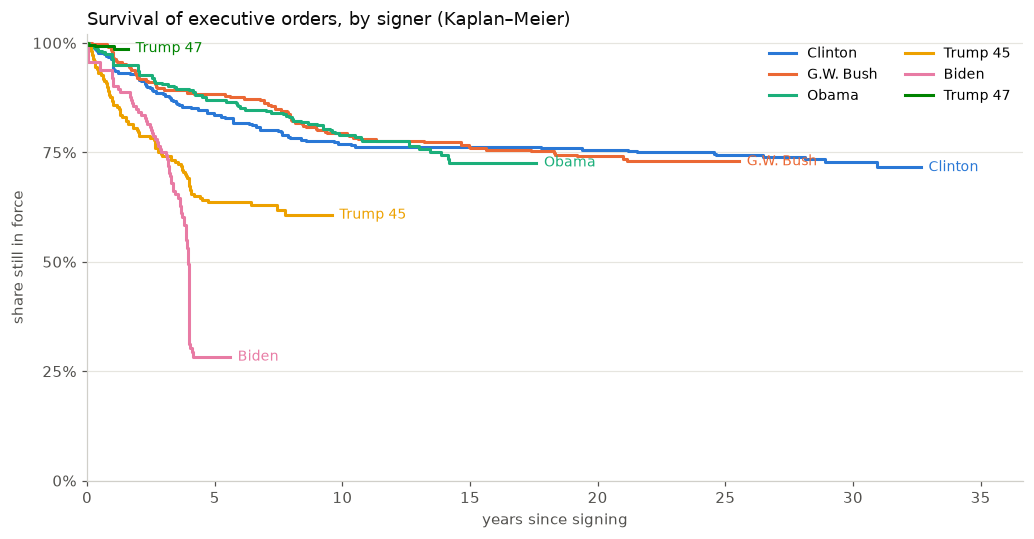

In [25]:
# Categorical slots 1-6 of the reference palette, in fixed order (never cycled).
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]

fig, ax = plt.subplots(figsize=(9.5, 5))
for colour, actor in zip(SERIES, ADMINS):
    c = curves[actor]
    # extend the step to the end of follow-up so the curve shows how long it was watched
    xs = np.append(c.years.values, FOLLOW_UP[actor]); ys = np.append(c.survival.values, c.survival.values[-1])
    ax.step(xs, ys, where="post", color=colour, linewidth=2, label=actor)
    ax.text(xs[-1] + 0.3, ys[-1], actor, va="center", fontsize=9, color=colour)
ax.set_ylim(0, 1.02); ax.set_xlim(0, FOLLOW_UP["Clinton"] + 4)
ax.set_yticks([0, .25, .5, .75, 1], ["0%", "25%", "50%", "75%", "100%"])
ax.set_xlabel("years since signing", color=MUTED)
ax.set_ylabel("share still in force", color=MUTED)
ax.set_title("Survival of executive orders, by signer (Kaplan–Meier)", loc="left", fontsize=12, color=INK)
ax.legend(frameon=False, loc="upper right", fontsize=9, ncol=2)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color("#d0cfc9"); ax.spines["bottom"].set_color("#d0cfc9")
ax.yaxis.grid(True, color="#e6e5df", linewidth=0.8); ax.set_axisbelow(True)
ax.tick_params(colors=MUTED)
plt.tight_layout()
plt.show()

Who does the revoking. Cumulative incidence at four years — the probability that an
order has been revoked in full by then, split by whether the signer or a successor did
it. Four years is chosen because it is the horizon every completed term reaches;
Trump 47 has not, and is shown at its own follow-up.

In [26]:
def cumulative_incidence(years, fate, horizon):
    """Aalen-Johansen: probability of each fate by `horizon`, in the presence of the other."""
    t = np.asarray(years, float); f = np.asarray(fate)
    times = np.unique(t[f != "in force / censored"])
    s_prev, cif = 1.0, {"revoked by signer": 0.0, "revoked by successor": 0.0}
    for ti in times:
        if ti > horizon:
            break
        at_risk = (t >= ti).sum()
        for k in cif:
            cif[k] += s_prev * ((t == ti) & (f == k)).sum() / at_risk
        s_prev *= 1 - ((t == ti) & (f != "in force / censored")).sum() / at_risk
    return cif


rows = []
for actor in ADMINS:
    g = life[life.actor == actor]
    h = min(4.0, FOLLOW_UP[actor])
    cif = cumulative_incidence(g.years, g.fate, h)
    rows.append({"signer": actor, "horizon (yrs)": round(h, 1),
                 "revoked by signer": f"{cif['revoked by signer']:.0%}",
                 "revoked by successor": f"{cif['revoked by successor']:.0%}",
                 "still in force": f"{1 - sum(cif.values()):.0%}"})
pd.DataFrame(rows).set_index("signer")

,horizon (yrs),revoked by signer,revoked by successor,still in force
signer,,,,
Clinton,4.0,11%,4%,85%
G.W. Bush,4.0,10%,2%,89%
Obama,4.0,7%,4%,89%
Trump 45,4.0,6%,27%,67%
Biden,4.0,6%,63%,31%
Trump 47,1.6,1%,0%,99%


Which *kinds* of order die young: survival at four years by instrument, across all
signers. Two effects to expect — annual pay orders (`adjusts_pay_or_admin`) are
superseded every year by design, and sanctions programmes are continued rather than
revoked.

In [27]:
rows = []
for inst, g in life.groupby("instrument"):
    curve = kaplan_meier(g.years, g.event)
    rows.append({"instrument": inst, "orders": len(g), "revoked": int(g.event.sum()),
                 "S(1 yr)": survival_at(curve, 1), "S(4 yrs)": survival_at(curve, 4),
                 "median (yrs)": median_survival(curve)})
inst_table = pd.DataFrame(rows).set_index("instrument").sort_values("S(4 yrs)")
for col in ("S(1 yr)", "S(4 yrs)"):
    inst_table[col] = inst_table[col].map(lambda v: f"{v:.0%}")
inst_table["median (yrs)"] = inst_table["median (yrs)"].map(lambda v: f"{v:.1f}" if pd.notna(v) else "not reached")
inst_table

,orders,revoked,S(1 yr),S(4 yrs),median (yrs)
instrument,,,,,
adjusts_pay_or_admin,62,48,61%,36%,1.0
directs_report_or_study,77,18,99%,72%,not reached
creates_body,435,143,97%,77%,not reached
delegates_authority,368,70,96%,82%,not reached
revokes_or_amends,337,69,96%,84%,not reached
other,84,13,95%,85%,not reached
imposes_sanctions,161,44,94%,88%,21.1
confers_status_or_honor,10,0,100%,100%,not reached


**Caveats that apply to this section.**

- An order is "revoked" here only when another executive order in this corpus revokes,
  rescinds or supersedes it in full, as recorded by the Federal Register or found by
  the model. Revocation by proclamation or memorandum, and expiry by an order's own
  sunset clause, are invisible: such orders count as still in force.
- Partial revocation is not an event, so an order gutted by amendments and partial
  revocations can survive here intact.
- The Federal Register's notes drive most events and are complete for what they cover;
  the model's added edges are precision-checked but their recall is unmeasured, so
  survival is if anything overstated.
- Curves for Biden and Trump 47 rest on short follow-up. Kaplan–Meier handles that
  correctly, but a four-year figure for Trump 47 is a projection from under two years
  of experience, and is marked as such.

### What gets reversed?

The survival section showed *that* successors reverse orders, and at very different
rates. This section asks *which* orders: given what an order is and when it was
signed, how much more or less likely is it to be revoked by the next administration?

**The outcome.** An order counts as reversed if the **immediate successor
administration revoked, rescinded or superseded it in full within its first 18
months**. The window is chosen because it is the follow-up Trump 47 has had, so
Biden's orders enter on the same footing as everyone else's; a four-year window on the
earlier signers is run afterwards as a check. Trump 47's own orders have no successor
and are excluded.

**The features.** Instrument and topic (each against its largest category), the
signer, how far into the term the order was signed, whether it came in the last 90
days, the number of agencies it tasks, its length, and whether it itself reversed an
order of the *previous* administration — the tit-for-tat hypothesis.

**The model.** A logistic regression with mild L2 regularisation; uncertainty from
300 bootstrap resamples, reported as 90% intervals on the odds ratios. Numeric
features are standardised, so their odds ratios are per one standard deviation.
Model-free reversal rates by category come first, because they need no model to be
read.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold

INAUGURATION = {"Clinton": "1993-01-20", "G.W. Bush": "2001-01-20", "Obama": "2009-01-20",
                "Trump 45": "2017-01-20", "Biden": "2021-01-20", "Trump 47": "2025-01-20"}
SUCCESSOR = dict(zip(ADMINS, ADMINS[1:]))
WINDOW_DAYS = int(1.5 * 365.25)

rv = life[life.actor != "Trump 47"].copy()
rv["term_start"] = pd.to_datetime(rv.actor.map(INAUGURATION))
rv["term_end"] = pd.to_datetime(rv.actor.map(SUCCESSOR).map(INAUGURATION))
rv["term_fraction"] = (rv.signed - rv.term_start).dt.days / (rv.term_end - rv.term_start).dt.days
rv["last_90_days"] = ((rv.term_end - rv.signed).dt.days <= 90).astype(int)

# Reversed: a full cancellation by the immediate successor inside the window.
succ = full.merge(rv[["document_number", "actor", "term_end"]].rename(columns={"actor": "tgt_actor"}),
                  left_on="tgt", right_on="document_number")
succ = succ[(succ.actor == succ.tgt_actor.map(SUCCESSOR))
            & ((succ.src_date - succ.term_end).dt.days <= WINDOW_DAYS)]
rv["reversed"] = rv.document_number.isin(succ.tgt).astype(int)

# Did this order itself cancel (in full or in part) an order of the previous administration?
PREDECESSOR = {v: k for k, v in SUCCESSOR.items()}
tit = edges[edges.target == edges.actor.map(PREDECESSOR)]
rv["reverses_predecessor"] = rv.document_number.isin(tit.src).astype(int)

n_agencies = pairs.groupby("document_number").canonical_name.nunique()
n_deadlines = q("SELECT document_number, COUNT(*) AS n FROM deadlines GROUP BY 1").set_index("document_number").n
chars = q("SELECT document_number, body_char_count FROM orders").set_index("document_number").body_char_count
rv["log_agencies"] = np.log1p(rv.document_number.map(n_agencies).fillna(0))
rv["log_deadlines"] = np.log1p(rv.document_number.map(n_deadlines).fillna(0))
rv["log_chars"] = np.log(rv.document_number.map(chars))

# Tiny categories fold into 'other' so the model does not fit a coefficient to three orders.
rv["topic"] = rv.primary_topic.replace({"tribal_affairs": "other"})
rv["instr"] = rv.instrument.replace({"confers_status_or_honor": "other"})

print(f"{len(rv)} orders with a successor; {rv.reversed.sum()} reversed within {WINDOW_DAYS} days "
      f"({rv.reversed.mean():.0%})")
rv.groupby("actor").reversed.agg(orders="size", reversed="sum", rate="mean").reindex(ADMINS[:-1]).assign(rate=lambda d: (d.rate * 100).round(0).astype(int))

1257 orders with a successor; 205 reversed within 547 days (16%)


,orders,reversed,rate
actor,,,
Clinton,308,16,5
G.W. Bush,291,20,7
Obama,276,19,7
Trump 45,220,66,30
Biden,162,84,52


Model-free first: the reversal rate by instrument and by topic, across the five
signers with a successor. These are raw rates and carry the signer mix inside them —
a topic Biden favoured will look reversal-prone because Biden's orders were.

In [29]:
def rate_table(col):
    t = rv.groupby(col).reversed.agg(orders="size", reversed="sum", rate="mean")
    t["rate"] = (t.rate * 100).round(0).astype(int)
    return t.sort_values("rate", ascending=False)

pd.concat({"by instrument": rate_table("instr")}, axis=0)

orders  reversed  rate
              instr                                          
by instrument directs_report_or_study      57        16    28
              creates_body                391        82    21
              delegates_authority         251        47    19
              adjusts_pay_or_admin         61        11    18
              revokes_or_amends           288        35    12
              other                        81         9    11
              imposes_sanctions           128         5     4

In [30]:
pd.concat({"by topic": rate_table("topic")}, axis=0)

orders  reversed  rate
         topic                                              
by topic immigration                      17         9    53
         education                        46        17    37
         economy_and_finance              34         8    24
         justice_and_law_enforcement      96        19    20
         energy_and_environment          151        29    19
         government_administration       342        62    18
         technology_and_research         103        19    18
         labor_and_workforce              57         9    16
         health                           92        14    15
         other                            27         4    15
         civil_rights                     37         4    11
         security_and_defense             66         6     9
         foreign_policy                  154         5     3
         trade                            35         0     0

In [31]:
rate_table("reverses_predecessor").rename(index={0: "did not reverse a predecessor", 1: "reversed a predecessor"})

,orders,reversed,rate
reverses_predecessor,,,
reversed a predecessor,127,49,39
did not reverse a predecessor,1130,156,14


The model. Odds ratios above 1 mean more likely to be reversed *holding the other
features fixed*; the signer terms absorb the large differences between
administrations, so the instrument and topic effects are within-signer.

In [32]:
REF = {"instr": "creates_body", "topic": "government_administration", "actor": "Clinton"}
NUMERIC = ["term_fraction", "log_agencies", "log_deadlines", "log_chars"]
BINARY = ["last_90_days", "reverses_predecessor"]


def design(df):
    X = pd.DataFrame(index=df.index)
    for col, ref in REF.items():
        for level in sorted(df[col].unique()):
            if level != ref:
                X[f"{col}: {level}"] = (df[col] == level).astype(float)
    for col in NUMERIC:
        X[col] = (df[col] - rv[col].mean()) / rv[col].std()
    for col in BINARY:
        X[col] = df[col].astype(float)
    return X


X = design(rv); y = rv.reversed.values
model = LogisticRegression(C=1.0, max_iter=5000)
cv_prob = cross_val_predict(model, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]
print(f"cross-validated AUC {roc_auc_score(y, cv_prob):.2f}  (0.5 = no better than chance; 1 = perfect)")

model.fit(X, y)
rng = np.random.default_rng(0)
boots = []
for _ in range(300):
    idx = rng.integers(0, len(X), len(X))
    boots.append(LogisticRegression(C=1.0, max_iter=5000).fit(X.iloc[idx], y[idx]).coef_[0])
boots = np.array(boots)
ors = pd.DataFrame({
    "odds ratio": np.exp(model.coef_[0]),
    "low (5%)": np.exp(np.percentile(boots, 5, axis=0)),
    "high (95%)": np.exp(np.percentile(boots, 95, axis=0)),
}, index=X.columns)
ors["clear of 1"] = (ors["low (5%)"] > 1) | (ors["high (95%)"] < 1)
ors.round(2).sort_values("odds ratio", ascending=False)

cross-validated AUC 0.83  (0.5 = no better than chance; 1 = perfect)


,odds ratio,low (5%),high (95%),clear of 1
actor: Biden,9.44,6.45,15.49,True
actor: Trump 45,4.81,3.24,7.63,True
topic: immigration,2.48,1.19,4.43,True
last_90_days,2.25,1.23,3.72,True
log_chars,1.81,1.54,2.25,True
reverses_predecessor,1.79,1.18,3.00,True
topic: education,1.73,1.05,2.94,True
topic: other,1.32,0.62,2.63,False
instr: adjusts_pay_or_admin,1.16,0.63,2.22,False
instr: directs_report_or_study,1.15,0.64,1.87,False


The same table as a picture, without the signer terms (which are large, expected, and
would compress everything else). A point is the odds ratio; the bar is its 90%
interval; anything whose bar crosses the line at 1 is not distinguishable from no
effect.

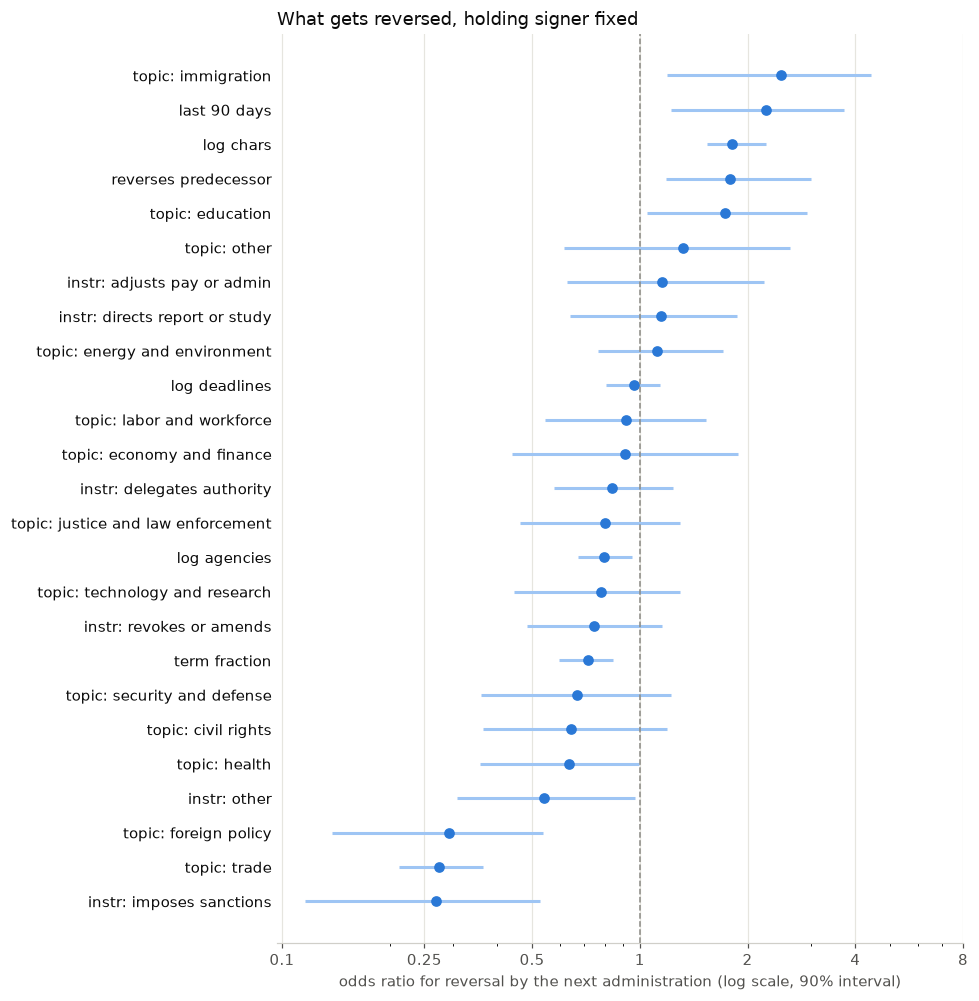

In [33]:
show = ors[~ors.index.str.startswith("actor:")].sort_values("odds ratio")
fig, ax = plt.subplots(figsize=(9, 0.32 * len(show) + 1.2))
ys = np.arange(len(show))
ax.hlines(ys, show["low (5%)"], show["high (95%)"], color="#9ec5f4", linewidth=2)
ax.plot(show["odds ratio"], ys, "o", color="#2a78d6", markersize=6)
ax.axvline(1, color="#8a8983", linewidth=1, linestyle="--")
ax.set_xscale("log")
ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4, 8], ["0.1", "0.25", "0.5", "1", "2", "4", "8"])
ax.set_yticks(ys, [s.replace("_", " ") for s in show.index])
ax.set_xlabel("odds ratio for reversal by the next administration (log scale, 90% interval)", color=MUTED)
ax.set_title("What gets reversed, holding signer fixed", loc="left", fontsize=12, color=INK)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d0cfc9")
ax.tick_params(axis="y", length=0, colors=INK); ax.tick_params(axis="x", colors=MUTED)
ax.xaxis.grid(True, color="#e6e5df", linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Check: a four-year window on the signers whose successor served four years.** If
the 18-month window is doing something odd, the strongest effects should move.

In [34]:
rv4 = rv[rv.actor != "Biden"].copy()
succ4 = full.merge(rv4[["document_number", "actor", "term_end"]].rename(columns={"actor": "tgt_actor"}),
                   left_on="tgt", right_on="document_number")
succ4 = succ4[(succ4.actor == succ4.tgt_actor.map(SUCCESSOR)) & ((succ4.src_date - succ4.term_end).dt.days <= 4 * 365.25)]
rv4["reversed"] = rv4.document_number.isin(succ4.tgt).astype(int)
X4, y4 = design(rv4), rv4.reversed.values
m4 = LogisticRegression(C=1.0, max_iter=5000).fit(X4, y4)
check = pd.DataFrame({"18 months, 5 signers": ors["odds ratio"],
                      "4 years, 4 signers": pd.Series(np.exp(m4.coef_[0]), index=X4.columns)})
check = check[~check.index.str.startswith("actor:")]
print(f"{len(rv4)} orders, {y4.sum()} reversed within four years ({y4.mean():.0%})")
check.round(2).sort_values("18 months, 5 signers", ascending=False)

1095 orders, 155 reversed within four years (14%)


,"18 months, 5 signers","4 years, 4 signers"
topic: immigration,2.48,1.65
last_90_days,2.25,1.81
log_chars,1.81,1.79
reverses_predecessor,1.79,2.66
topic: education,1.73,2.23
topic: other,1.32,1.29
instr: adjusts_pay_or_admin,1.16,1.06
instr: directs_report_or_study,1.15,0.94
topic: energy_and_environment,1.11,0.89
log_deadlines,0.96,1.07


**Caveats that apply to this section.**

- **Every succession in this corpus is a change of party**, so "reversed by the
  successor" and "reversed by the other party" cannot be separated here. The signer
  terms carry the era effect; nothing in the model says what a same-party handover
  would look like.
- Reversal is measured only through executive orders that revoke in full (see the
  survival section's caveats). An order neutralised by amendment or by a memorandum
  counts as not reversed.
- The corpus starts in December 1993, so Clinton's first year is missing; his
  early-term orders are under-represented and his `term_fraction` is skewed late.
- Odds ratios come from a regularised model and 300 bootstrap resamples on about 1,250
  orders. Wide intervals on small categories (`immigration`, `economy_and_finance`)
  are the data being honest, not a defect to tune away.
- `trade` has **no reversal at all** in the sample (0 of 35), so its odds ratio is the
  regulariser's estimate of a quantity the data put at zero; read it as "very low",
  not as 0.28. The tight interval is the regulariser, not the data.
- `term_fraction` and `last_90_days` are read together: the flag carries the
  end-of-term spike, and the fraction the trend across the rest of the term.
- `primary_topic` carries the classification caveats from earlier sections; a topic
  effect is an effect of the *label*.